# OSMnx 功能演示

Author: [Geoff Boeing](https://geoffboeing.com/)

从OpenStreetMap获取全球任意位置的街道网络和其他地理空间特征数据，并进行建模、分析和可视化。

更多信息:

  - [Documentation](https://osmnx.readthedocs.io/)
  - [Journal article and citation info](https://doi.org/10.1111/gean.70009)
  - [Code repository](https://github.com/gboeing/osmnx)
  - [Examples gallery](https://github.com/gboeing/osmnx-examples)
  
本笔记本快速展示了OSMnx的一些关键功能，包括如何:

- 下载/建模街道网络
- 计算统计数据
- 可视化中心性
- 估算速度/行程时间并计算最短路径
- 附加并可视化高程数据和边缘坡度
- 下载/建模其他基础设施类型
- 下载兴趣点数据

In [1]:
# if using colab, install dependencies by un-commenting the line below
#!uv pip install --system --quiet osmnx[all]

In [2]:
import networkx as nx
import osmnx as ox

ox.__version__

'2.0.6'

## Working with street networks

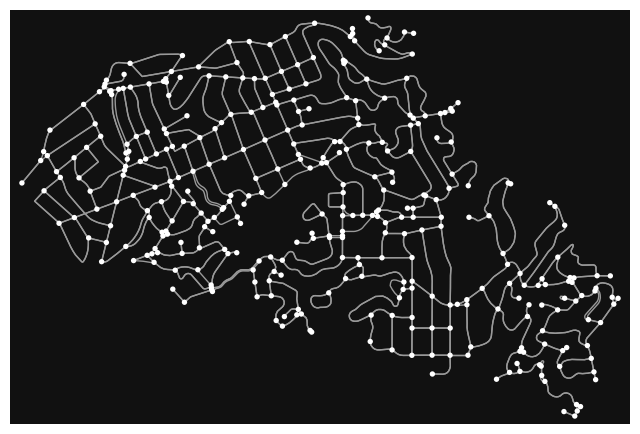

In [3]:
# 下载/建模某个城市的街道网络并可视化
G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive")
fig, ax = ox.plot.plot_graph(G)

OSMnx 对查询 "Piedmont, California, USA" 进行地理编码，从 Nominatim API 获取该城市的边界，然后从 Overpass API 获取这些边界内的可驾驶街道网络数据，构建图模型，并简化/校正其拓扑结构，使节点表示交叉路口和死胡同，边表示连接它们的街道段。所有这些都在文档和这些示例中有详细讨论。

OSMnx 将所有网络建模为 NetworkX MultiDiGraph 对象。您可以转换为：
- 无向 MultiGraphs
- 不带(可能)平行边的 DiGraphs
- GeoPandas 节点/边 GeoDataFrames

请注意，转换为无向 MultiGraph 仅适用于函数或算法只接受 MultiGraph 参数的情况。如果您只想要一个完全双向的图(例如步行网络)，只需在创建图之前配置 settings 模块的 bidirectional_network_types

In [4]:
# 获取一个完全双向的网络（作为MultiDiGraph）
ox.settings.bidirectional_network_types += "drive"
G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive")

# 将MultiDiGraph转换为无向的MultiGraph
M = ox.convert.to_undirected(G)

# 将MultiDiGraph转换为没有平行边的DiGraph
D = ox.convert.to_digraph(G)

In [5]:
# 你可以将图转换为节点和边的GeoPandas GeoDataFrames
gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(G)
gdf_nodes.head()

,y,x,street_count,highway,junction,geometry
osmid,,,,,,
53017091,37.826250,-122.247604,3,NaN,NaN,POINT (-122.2476 37.82625)
53018397,37.824220,-122.247198,3,stop,NaN,POINT (-122.2472 37.82422)
53018399,37.824900,-122.246113,3,NaN,NaN,POINT (-122.24611 37.8249)
53018402,37.825406,-122.245338,3,NaN,NaN,POINT (-122.24534 37.82541)
53018404,37.825948,-122.244467,3,NaN,NaN,POINT (-122.24447 37.82595)


In [6]:
gdf_edges.head()

osmid      highway          name  oneway reversed  \
u        v        key                                                          
53017091 53064327 0      6345781  residential   Rose Avenue   False    False   
         53075599 0      6345781  residential   Rose Avenue   False     True   
53018397 53018399 0      6327298  residential   Lake Avenue   False    False   
         53018411 0    196739937     tertiary  Linda Avenue   False    False   
         53097980 0    196739937     tertiary  Linda Avenue   False     True   

                           length  \
u        v        key               
53017091 53064327 0    230.124412   
         53075599 0    122.234915   
53018397 53018399 0    121.647438   
         53018411 0     37.593760   
         53097980 0    100.205124   

                                                                geometry  \
u        v        key                                                      
53017091 53064327 0    LINESTRING (-122.2476 37.82625, -122.2475 37.8...   
         53075599 0    LINESTRING (-122.2476 37.82625, -122.24771 37....   
53018397 53018399 0    LINESTRING (-122.2472 37.82422, -122.24712 37....   
         53018411 0    LINESTRING (-122.2472 37.82422, -122.24713 37....   
         53097980 0    LINESTRING (-122.2472 37.82422, -122.24772 37....   

                      lanes maxspeed bridge junction  
u        v        key                                 
53017091 53064327 0     NaN      NaN    NaN      NaN  
         53075599 0     NaN      NaN    NaN      NaN  
53018397 53018399 0     NaN      NaN    NaN      NaN  
         53018411 0     NaN      NaN    NaN      NaN  
         53097980 0     NaN      NaN    NaN      NaN

你可以从节点/边的GeoDataFrames创建图，只要gdf_nodes按osmid索引且gdf_edges按u、v、key多重索引（遵循正常的MultiDiGraph结构）。

这允许你加载图节点/边的ShapeFiles或GeoPackage图层作为GeoDataFrames，然后转换为MultiDiGraph进行图分析。

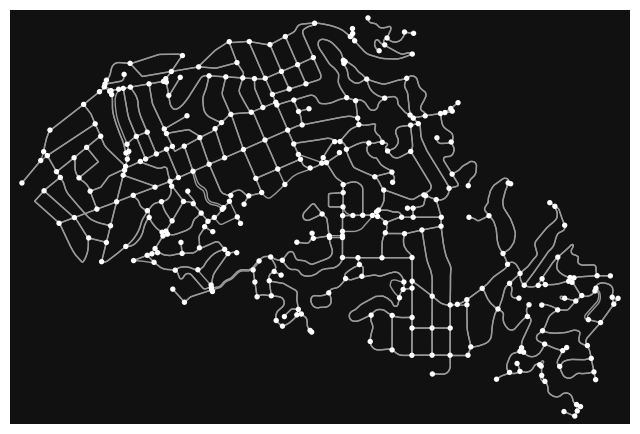

In [8]:
# 将节点/边的GeoPandas GeoDataFrames转换为NetworkX MultiDiGraph
G2 = ox.convert.graph_from_gdfs(gdf_nodes, gdf_edges, graph_attrs=G.graph)
fig, ax = ox.plot.plot_graph(G2)

## Basic street network stats

In [12]:
# 我们的网络覆盖了多少平方米的区域？
G_proj = ox.projection.project_graph(G)
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.union_all().convex_hull.area
graph_area_m

4199465.640327132

In [13]:
# 显示网络的一些基本统计信息
ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

{'n': 352,
 'm': 944,
 'k_avg': 5.363636363636363,
 'edge_length_total': 112049.01053896977,
 'edge_length_avg': 118.69598574043408,
 'streets_per_node_avg': 2.9488636363636362,
 'streets_per_node_counts': {0: 0, 1: 34, 2: 0, 3: 270, 4: 46, 5: 2},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.09659090909090909,
  2: 0.0,
  3: 0.7670454545454546,
  4: 0.13068181818181818,
  5: 0.005681818181818182},
 'intersection_count': 318,
 'street_length_total': 58086.34612850781,
 'street_segment_count': 495,
 'street_length_avg': 117.34615379496528,
 'circuity_avg': 1.1112792110333796,
 'self_loop_proportion': 0.006060606060606061,
 'clean_intersection_count': 267,
 'node_density_km': 83.82018812578728,
 'intersection_density_km': 75.72391995454646,
 'edge_density_km': 26681.73051899082,
 'street_density_km': 13831.8422159975,
 'clean_intersection_density_km': 63.57951769768524}

stats documentation: https://osmnx.readthedocs.io/en/stable/osmnx.html#module-osmnx.stats

In [14]:
# 将图保存为geopackage格式(用于GIS)或graphml文件(用于gephi等)
ox.io.save_graph_geopackage(G, filepath="./data/mynetwork.gpkg")
ox.io.save_graphml(G, filepath="./data/mynetwork.graphml")

## 可视化街道中心性

这里我们绘制街道网络，并根据其相对接近中心性为边(街道)着色。

In [15]:
# 将图转换为线图，使边变为节点，节点变为边
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, "edge_centrality")

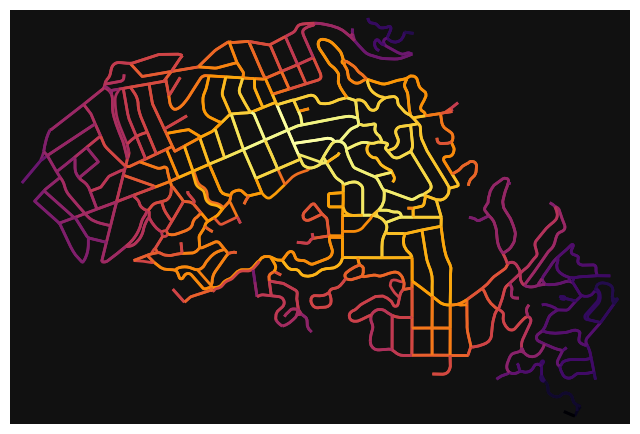

In [16]:
# 使用线图中的接近中心性为原始图中的边着色
ec = ox.plot.get_edge_colors_by_attr(G, "edge_centrality", cmap="inferno")
fig, ax = ox.plot.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)

## Routing

In [17]:
# 使用speed模块估算缺失的边速度并计算边行程时间
G = ox.routing.add_edge_speeds(G)
G = ox.routing.add_edge_travel_times(G)

In [18]:
# 使用distance模块获取两个经纬度点最近的网络节点
orig = ox.distance.nearest_nodes(G, X=-122.245846, Y=37.828903)
dest = ox.distance.nearest_nodes(G, X=-122.215006, Y=37.812303)

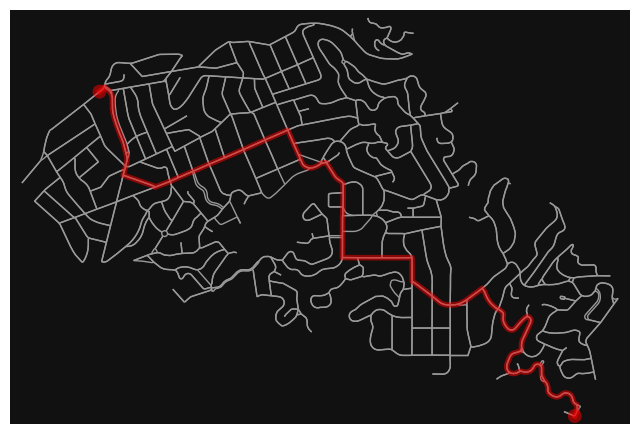

In [19]:
# 查找节点间的最短路径(最小化行程时间)并绘制
route = ox.routing.shortest_path(G, orig, dest, weight="travel_time")
fig, ax = ox.plot.plot_graph_route(G, route, node_size=0)

In [20]:
# 我们的路线长度是多少米？
edge_lengths = ox.routing.route_to_gdf(G, route)["length"]
round(sum(edge_lengths))

4761

In [21]:
# 这两个节点之间的直线距离是多少？
# 使用OSMnx的向量化大圆距离(haversine)函数
orig_x = G.nodes[orig]["x"]
orig_y = G.nodes[orig]["y"]
dest_x = G.nodes[dest]["x"]
dest_y = G.nodes[dest]["y"]
round(ox.distance.great_circle(orig_y, orig_x, dest_y, dest_x))

3124

你可以使用`elevation`模块自动为图的节点添加高程属性，可以使用本地栅格文件或Google Maps Elevation API。

In [23]:
# 自动为节点添加高程，计算边坡度，绘制网络图
# 你需要一个Google Elevation API密钥来运行这个单元格！
try:
    from keys import google_elevation_api_key

    G = ox.elevation.add_node_elevations_google(G, api_key=google_elevation_api_key)
    G = ox.elevation.add_edge_grades(G)
    nc = ox.plot.get_node_colors_by_attr(G, "elevation", cmap="plasma")
    fig, ax = ox.plot.plot_graph(
        G,
        node_color=nc,
        node_size=20,
        edge_linewidth=2,
        edge_color="#333",
    )
except ImportError:
    print("你需要一个google_elevation_api_key来运行这个单元格。")

你需要一个google_elevation_api_key来运行这个单元格。


节点颜色从最低高程（深蓝色）到最高高程（亮黄色）渐变。

示例：创建[elevation-based](12-node-elevations-edge-grades.ipynb)阻抗函数来绕过山丘。

## 获取网络的其他方式

减少查询的歧义性以帮助地理编码器，如果它没有找到你要找的内容

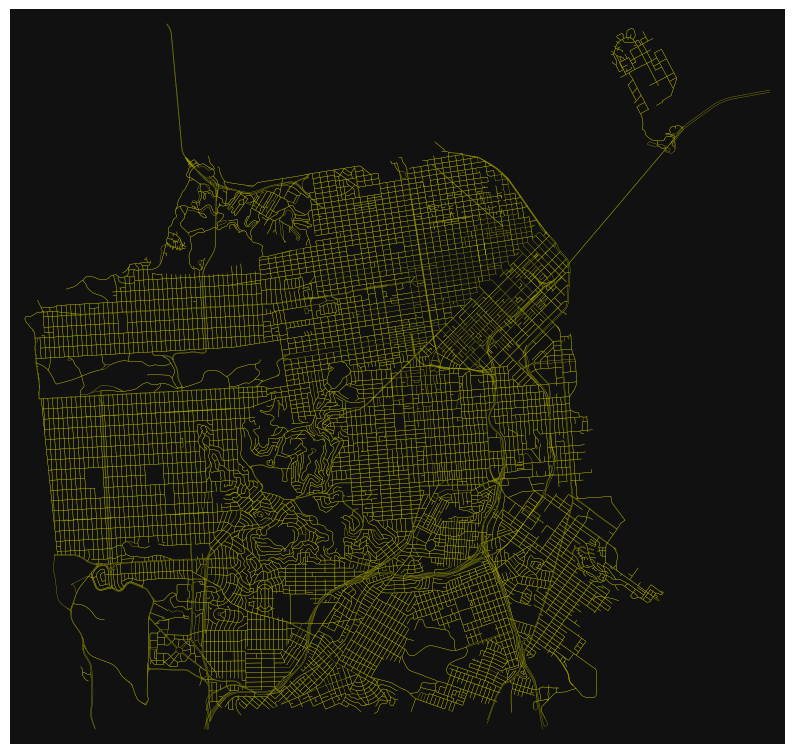

In [24]:
# 你可以使用明确的字典查询来帮助地理编码器找到位置
place = {"city": "San Francisco", "state": "California", "country": "USA"}
G = ox.graph.graph_from_place(place, network_type="drive", truncate_by_edge=True)
fig, ax = ox.plot.plot_graph(G, figsize=(10, 10), node_size=0, edge_color="y", edge_linewidth=0.2)

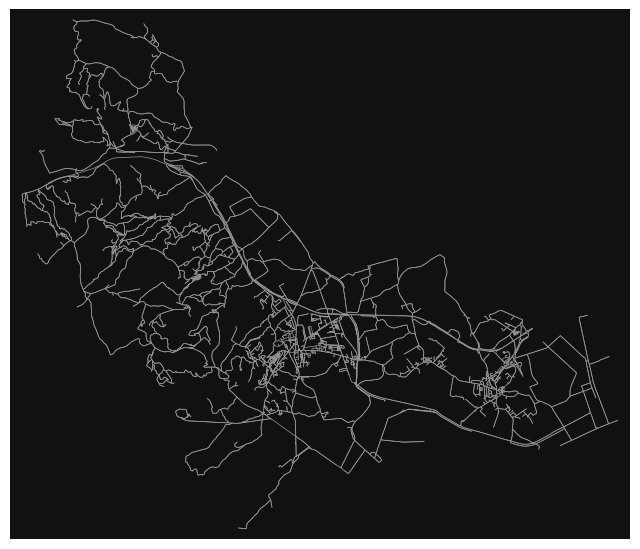

In [25]:
# 你可以在世界任何地方获取街道网络
G = ox.graph.graph_from_place("Sinalunga, Italy", network_type="all")
fig, ax = ox.plot.plot_graph(G, node_size=0, edge_linewidth=0.5)

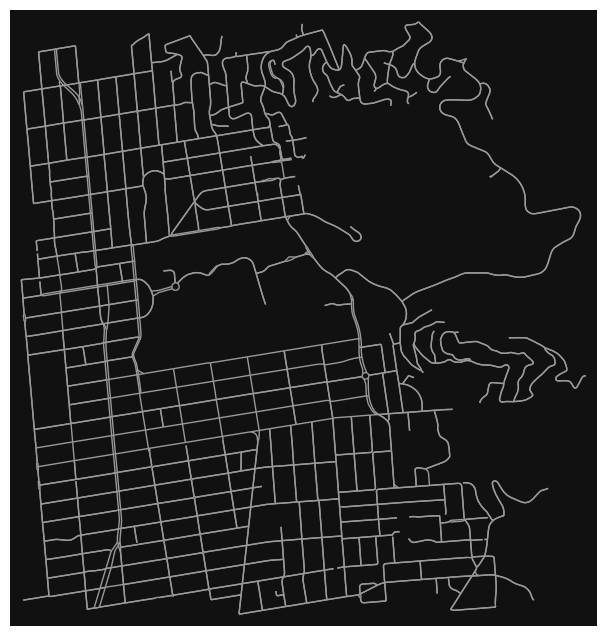

In [26]:
# 也可以通过地址、坐标、边界框或任何自定义多边形获取网络
# 当OSM没有你所需位置的现有多边形时特别有用
wurster_hall = (37.870605, -122.254830)  # 坐标点
one_mile = 1609  # 1英里=1609米
G = ox.graph.graph_from_point(wurster_hall, dist=one_mile, network_type="drive")
fig, ax = ox.plot.plot_graph(G, node_size=0)

Examples of [getting networks](01-overview-osmnx.ipynb) by 坐标、边界框或任何自定义多边形形状

## 获取其他类型的基础设施网络

...如铁路、电网甚至威尼斯和阿姆斯特丹的运河，使用`custom_filter`参数：[查看更多示例](08-custom-filters-infrastructure.ipynb)

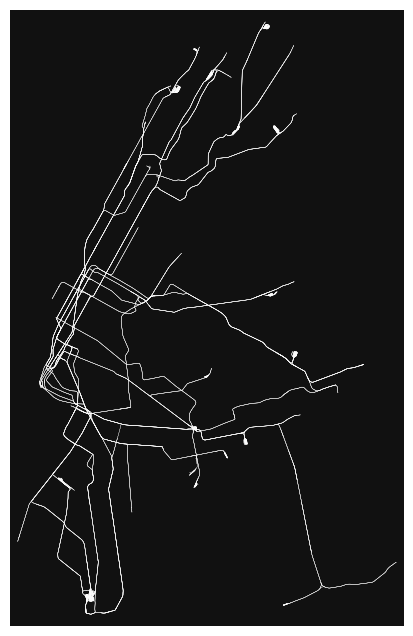

In [27]:
# 获取纽约地铁网络
G = ox.graph.graph_from_place(
    "New York, New York, USA",
    retain_all=False,  # 不保留所有节点
    truncate_by_edge=True,  # 按边界截断
    simplify=True,  # 简化网络
    custom_filter='["railway"~"subway"]',  # 自定义过滤器只获取地铁
)

# 绘制地铁网络图
fig, ax = ox.plot.plot_graph(G, node_size=0, edge_color="w", edge_linewidth=0.2)

## 获取地理空间要素的几何和属性

使用`features`模块下载任何OSM要素，如本地设施、兴趣点或建筑轮廓，并将其转换为GeoDataFrame：[查看文档](https://osmnx.readthedocs.io/en/stable/osmnx.html#module-osmnx.features)。

更多从OSM下载地理空间要素的示例，请参阅[此笔记本](16-download-osm-geospatial-features.ipynb)。

In [28]:
# 获取某社区的所有建筑足迹
place = "Chinatown, San Francisco, California"
tags = {"building": True}
gdf = ox.features.features_from_place(place, tags)
gdf.shape

(566, 104)

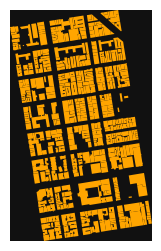

In [29]:
fig, ax = ox.plot.plot_footprints(gdf, figsize=(3, 3))

查看其他notebook获取更多使用OSMnx进行可视化的示例。

In [31]:
# 获取某社区的所有公园和公交站点
tags = {"leisure": "park", "highway": "bus_stop"}
gdf = ox.features.features_from_place(place, tags)
gdf.shape

(21, 41)